In [1]:
import torchcurves.functional as tcf

from dataclasses import dataclass
import math

import matplotlib.pyplot as plt
import numpy as np
import scipy.special
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import trange

# Simulate auctions

In [2]:
@dataclass
class Seller:
    """Sellers have feature vectors, and draw auction features in the vicinity of those vectors"""
    features: np.typing.NDArray
    std: float

    @classmethod
    def draw_seller(cls, dim: int, rng: np.random.Generator):
        return cls(
            features=rng.standard_normal(size=dim),
            std=0.5 / math.sqrt(dim),
        )

    def draw_auction_features(self) -> np.typing.NDArray:
        return self.features + self.std * rng.standard_normal(len(self.features))

@dataclass
class Buyer:
    """Buyers have preference features, and bid higher the closer are their own preferences to auction features"""
    daily_budget: float
    budget: float
    preferences: np.typing.NDArray

    @classmethod
    def draw_player(cls, mean_budget: float, dim: int, rng: np.random.Generator):
        daily_budget = rng.exponential(scale=mean_budget)
        return cls(
            daily_budget=daily_budget,
            budget=daily_budget,
            preferences=rng.normal(size=dim),
        )

    def reset_budget(self):
        self.budget = self.daily_budget

    def bid(self, auction_features: np.typing.NDArray):
        # bid inversely proportional to the distance from preferences to features
        dist = np.linalg.norm(self.preferences - auction_features, 1)
        desired_bid = np.reciprocal(dist)
        return min(self.budget, desired_bid)

    def charge(self, amount: float):
        self.budget -= amount

In [3]:
n_buyers = 15     # we and (n_buyers - 1) competitors
n_sellers = 10

feature_dim = 3
n_daily_auctions = 2000
n_days = 5
mean_buyer_budget = n_daily_auctions / n_buyers
rng = np.random.default_rng(42)

In [4]:
buyers = [Buyer.draw_player(mean_buyer_budget, feature_dim, rng) for _ in range(n_buyers)]
sellers = [Seller.draw_seller(feature_dim, rng) for _ in range(n_sellers)]

player_prefs = np.vstack([player.preferences for player in buyers])
seller_weights = scipy.special.softmax(rng.uniform(size=n_sellers))

# a list to store the features of each auction
auction_feature_log = []
budget_fraction_log = []

# lists to store auction results
our_idx = 0   # we are the first buyer
our_bids = []
our_wins = []

for day in trange(n_days, leave=True):
    for i in trange(n_daily_auctions, leave=False):
        # draw a seller and let the them choose auction features
        seller = sellers[rng.choice(n_sellers, p=seller_weights)]
        current_auction_features = seller.draw_auction_features()

        # budgets submit bids
        bids = np.asarray([player.bid(current_auction_features) for player in buyers])
        our_bid = bids[our_idx]

        # store features and bids
        auction_feature_log.append(current_auction_features)
        budget_fraction_log.append(buyers[our_idx].budget / buyers[our_idx].daily_budget)
        our_bids.append(our_bid)

        # determine and charge the winner, and log if we won
        has_winner = np.any(bids > 0)
        if has_winner:
            winner_idx = np.argmax(bids).item()
            buyers[winner_idx].charge(bids[winner_idx])
            our_wins.append(1. if winner_idx == our_idx else 0.)
        else:
            our_wins.append(0.)

    for buyer in buyers:
        buyer.reset_budget()

auction_feature_log = np.vstack(auction_feature_log)
budget_fraction_log = np.asarray(budget_fraction_log)
our_bids = np.asarray(our_bids)
our_wins = np.asarray(our_wins)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

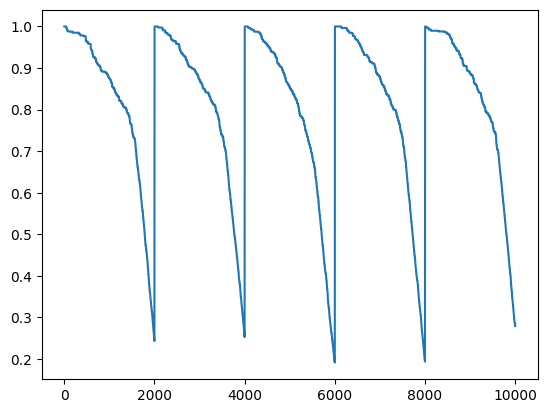

In [5]:
plt.plot(budget_fraction_log)

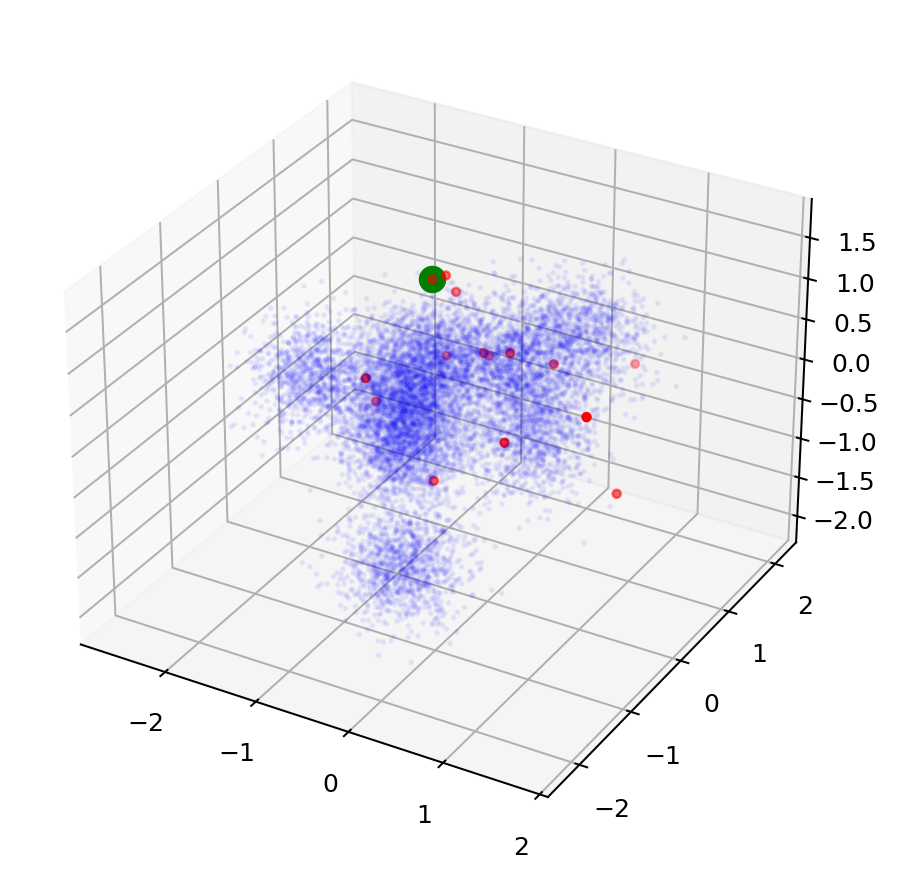

In [6]:
# plot sellers, auction features, and player preferences
# this is to see that auction features are indeed nicely clustered
# around the sellers
fig = plt.figure(dpi=180, figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(*np.hsplit(auction_feature_log, 3), c='blue', s=2, alpha=0.05)
ax.scatter(*np.hsplit(player_prefs, 3), c='red', s=10)
ax.scatter(*buyers[0].preferences, c='green', s=100)
plt.show()

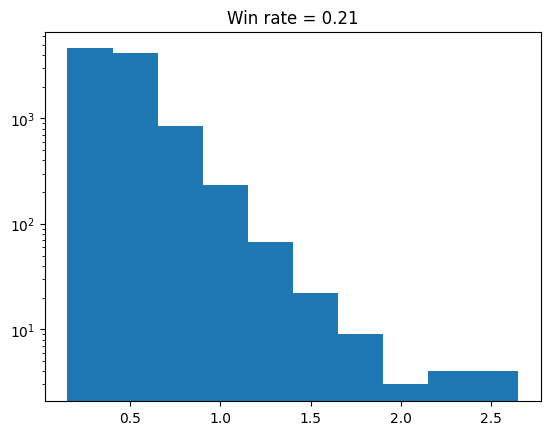

In [7]:
plt.hist(our_bids, log=True)
plt.title(f'Win rate = {our_wins.mean():.2f}')
plt.show()

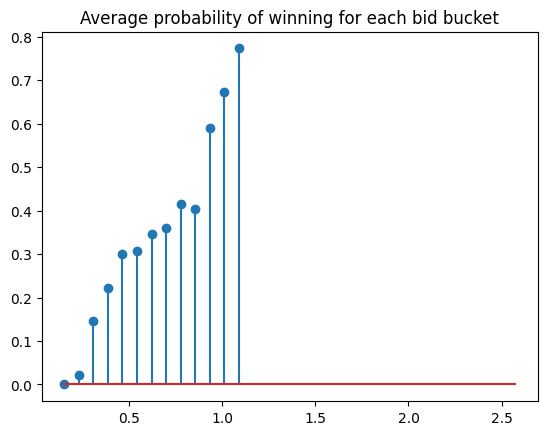

In [8]:
def bucket_means(b, p, n):
    # Uniform bucket edges on [min(b), max(b)]
    edges = np.linspace(b.min(), b.max(), n + 1)

    # Map each b to a bucket index in [0, n-1]
    idx = np.searchsorted(edges, b, side='right') - 1
    idx = np.clip(idx, 0, n - 1)

    # Weighted sum and counts per bucket
    sums = np.bincount(idx, weights=p, minlength=n)
    counts = np.bincount(idx, minlength=n)

    # Means, with zeros for empty buckets
    means = np.divide(sums, counts,
                      out=np.full(n, np.nan, dtype=float),
                      where=counts > 30)

    return edges[:-1], means

plt.stem(*bucket_means(our_bids, our_wins, 32))
plt.title('Average probability of winning for each bid bucket')
plt.show()

# Prepare train / validation data

In [9]:
def to_torch(mask, *arrays):
    tensors = (torch.as_tensor(t[mask], dtype=torch.get_default_dtype()) for t in arrays)
    return TensorDataset(*tensors)

In [10]:
# features include budget fractions
X = np.hstack((auction_feature_log, budget_fraction_log.reshape(-1, 1)))

In [11]:
train_frac = 0.8
train_mask = rng.random(size=X.shape[0]) < train_frac
train_ds = to_torch(train_mask, X, our_bids, our_wins)
val_ds = to_torch(~train_mask, X, our_bids, our_wins)
max_bid = np.max(our_bids).item()

# Define the model

In [12]:
def make_mlp(input_dim: int, output_dim: int, num_hidden_layers: int, hidden_dim: int):
        return nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            *(
                layer for _ in range(num_hidden_layers) for layer in [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
            ),
            nn.Linear(hidden_dim, output_dim),
        )

In [13]:
class BidModel(nn.Module):
    def __init__(self, input_dim: int, num_coefficients: int, num_hidden_layers: int):
        super().__init__()
        self.degree = 3
        hidden_dim = 8 * max(input_dim, num_coefficients)
        self.coef_model = make_mlp(input_dim, num_coefficients, num_hidden_layers, hidden_dim)
        self.register_buffer("knots", tcf.uniform_augmented_knots(num_coefficients, degree=self.degree, k_min=0, k_max=1))

    def forward(self, auction_features: torch.Tensor, bid: torch.Tensor) -> torch.Tensor:
        # map auction features to increasing spline coefficients via MLP + increasing transform
        coefficients = self.coef_model(auction_features)
        increasing_coefficients = self._make_increasing(coefficients)
        increasing_coefficients = increasing_coefficients.unsqueeze(-1)  # B x C x 1 (B curves with C coefficients in 1 dimension)

        # map bids to [0, 1] using the arctan (or any other) normalization
        mapped_bid = tcf.arctan(bid)
        mapped_bid = mapped_bid.unsqueeze(0)  # 1 x B (B curves in 1 dimension)

        # compute a B-Spline function that by-design increases with the bid!
        return tcf.bspline_curves(mapped_bid, increasing_coefficients, self.knots, self.degree).squeeze([0, -1])

    @staticmethod
    def _make_increasing(x):
        initial = x[..., :1]
        increments = nn.functional.softplus(x[..., 1:])
        concatenated = torch.concat((initial, increments), dim=-1)
        return torch.cumsum(concatenated, dim=-1)

In [14]:
# model params
num_coefficients = 20
num_hidden_layers = 10

# training params
num_epochs = 10
batch_size = 64
lr = 1e-4
weight_decay = 1e-6

# create model, loss, optimizer, and dataloaders
model = BidModel(X.shape[1], num_coefficients, num_hidden_layers)
loss = nn.BCEWithLogitsLoss()
opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

# training loop
for epoch in range(1, 1 + num_epochs):
    epoch_loss = torch.tensor(0.)
    for X_batch, bid_batch, win_batch in train_dl:
        opt.zero_grad()
        y_pred = model(X_batch, bid_batch)
        loss_val = loss(y_pred, win_batch)
        loss_val.backward()
        opt.step()

        with torch.no_grad():
            epoch_loss += loss_val * len(X_batch)
    epoch_loss /= len(train_ds)

    with torch.no_grad():
        for X_batch, bid_batch, win_batch in val_dl:
            y_pred = model(X_batch, bid_batch)
            valid_loss = loss(y_pred, win_batch)

    print(f'Epoch = {epoch}, Loss = {epoch_loss:.4f}, Valid Loss = {valid_loss:.4f}')

/home/alex/git/torchcurves/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch = 1, Loss = 1.7785, Valid Loss = 0.4303
Epoch = 2, Loss = 0.3479, Valid Loss = 0.2966
Epoch = 3, Loss = 0.2346, Valid Loss = 0.1947
Epoch = 4, Loss = 0.1785, Valid Loss = 0.1670
Epoch = 5, Loss = 0.1646, Valid Loss = 0.1586
Epoch = 6, Loss = 0.1530, Valid Loss = 0.1452
Epoch = 7, Loss = 0.1438, Valid Loss = 0.1432
Epoch = 8, Loss = 0.1391, Valid Loss = 0.1347
Epoch = 9, Loss = 0.1365, Valid Loss = 0.1413
Epoch = 10, Loss = 0.1355, Valid Loss = 0.1276


# Plot  f(bid) = P(win | auction, bid) for several auctions from the validation set

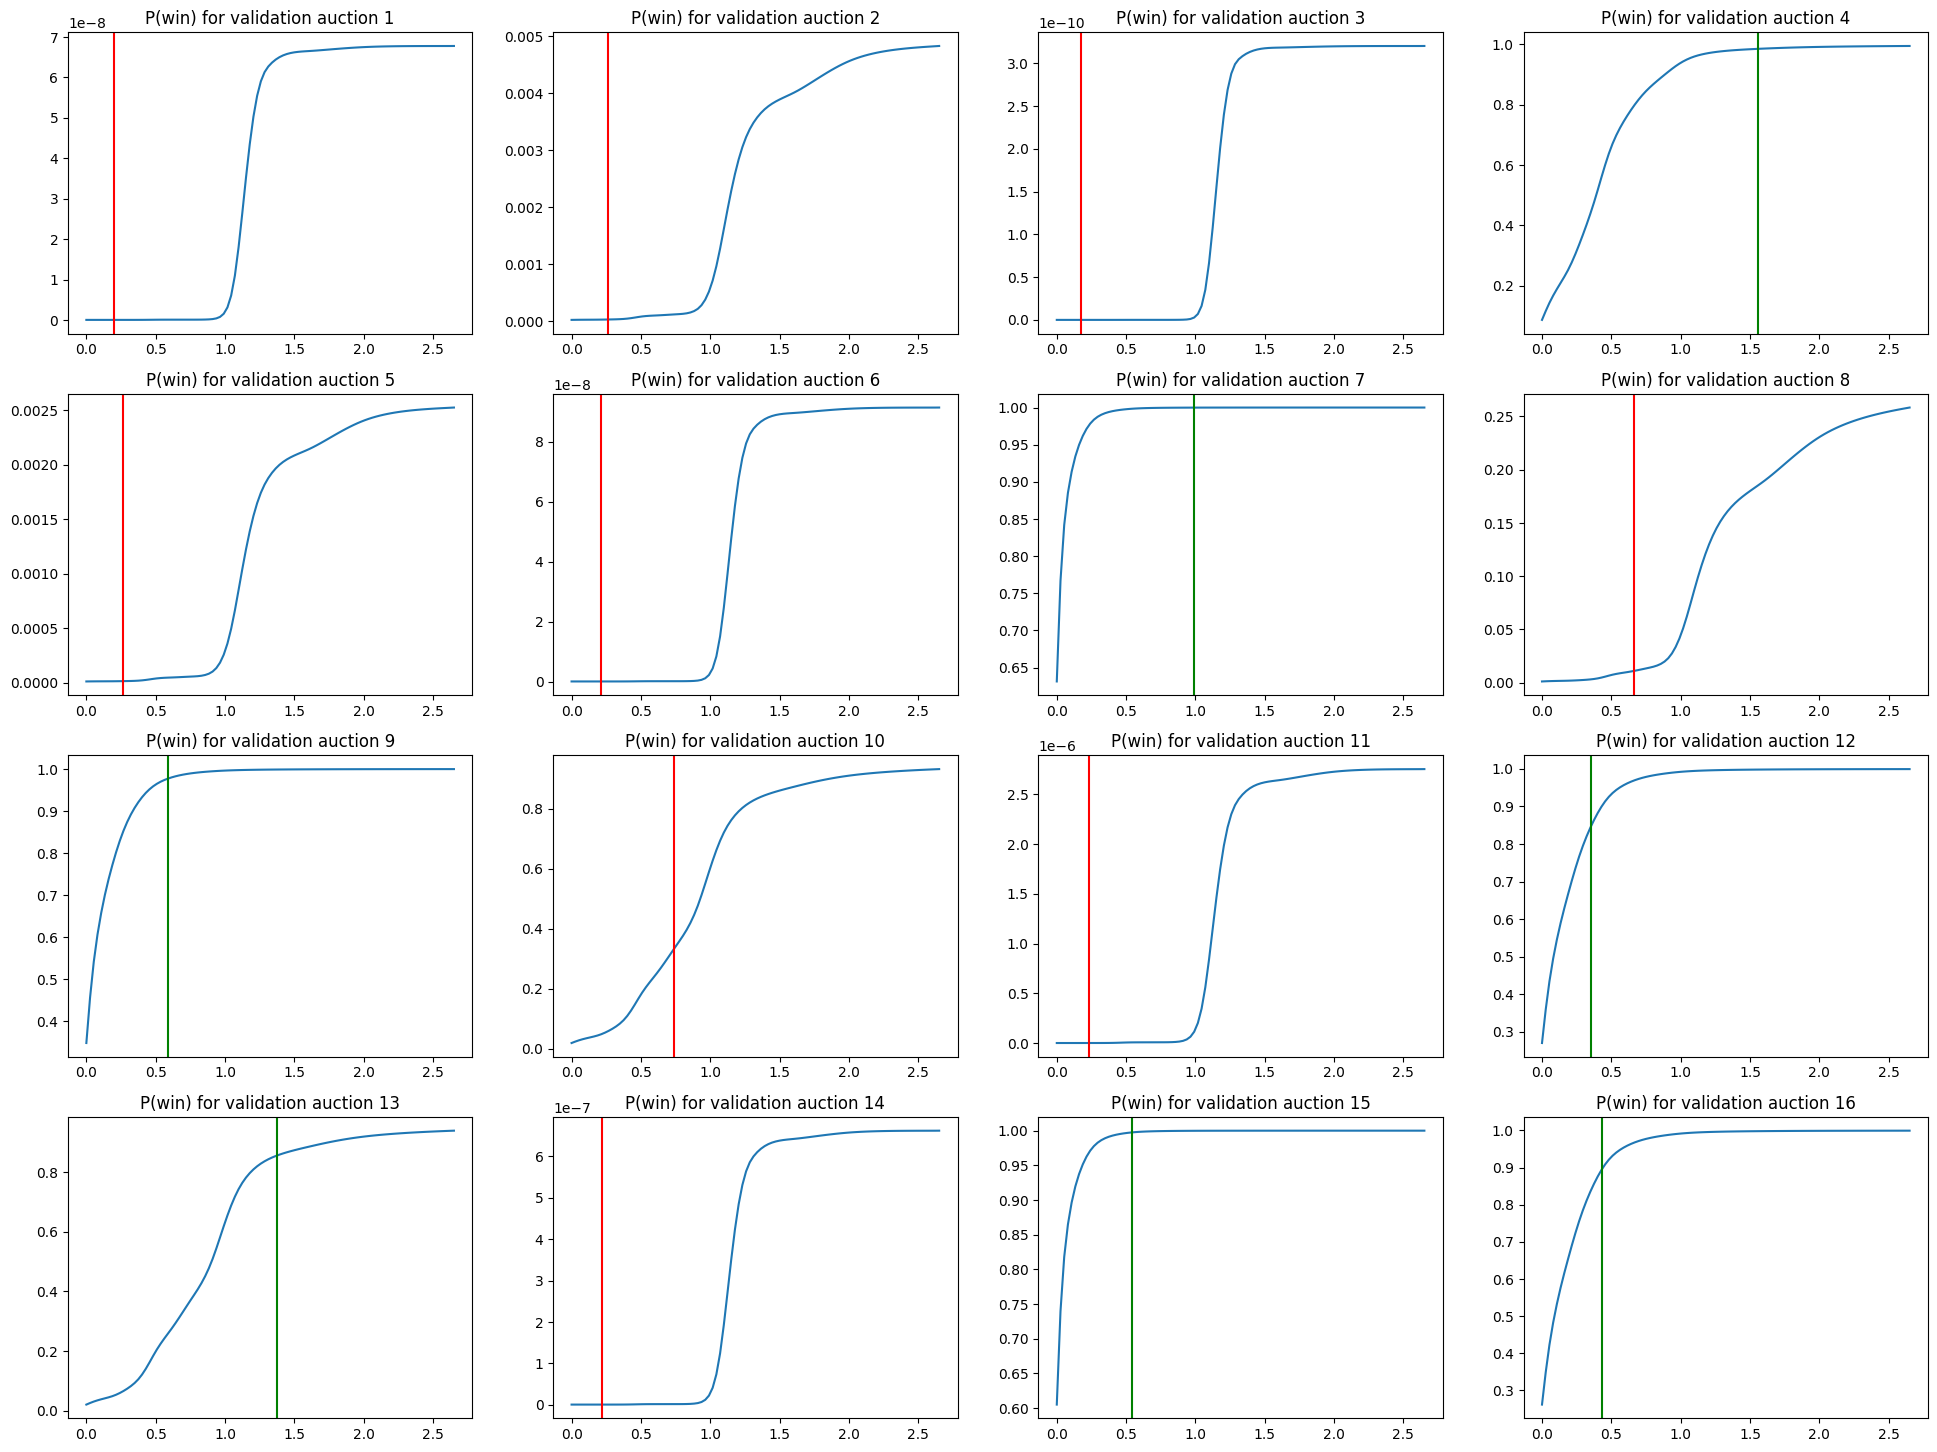

In [15]:
num_plots = 16
num_plot_cols = 4
num_plot_rows = int(np.ceil(num_plots / num_plot_cols).item())
plot_resolution = 100

fig, axs = plt.subplots(num_plot_rows, num_plot_cols, figsize=(6 * num_plot_cols, 4.5 * num_plot_rows))
plot_bids = torch.linspace(0, max_bid, plot_resolution)

random_auction_indices = rng.choice(len(val_ds), num_plots, replace=False).tolist()
plot_feat_batch, plot_bid_batch, plot_win_batch = val_ds[random_auction_indices]

for i, (ax, feats, bid, win) in enumerate(zip(axs.ravel(), plot_feat_batch, plot_bid_batch, plot_win_batch), start=1):
    with torch.no_grad():
        pred_logits = model(feats.expand(plot_resolution, -1), plot_bids)
        pred_probs = torch.sigmoid(pred_logits)
        mlp_output = model.coef_model(feats)

    ax.plot(plot_bids, pred_probs)
    ax.axvline(bid, color=('green' if win else 'red'))
    ax.set_title(f'P(win) for validation auction {i}')